<a href="https://colab.research.google.com/github/Maatpz/Analise-de-Dados/blob/main/atividade_pratica_aula1_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade Prática — Aula 1  
## Python para Análise de Dados: do dado bruto à decisão estratégica

Nesta atividade, você vai aplicar os conceitos apresentados na aula usando um dataset simulado de vendas no varejo brasileiro.

**Arquivo de dados:** `vendas_brasil_aula1.csv`  
**Objetivo:** praticar leitura de dados, inspeção inicial, qualidade dos dados, KPIs e escolha de visualizações.

---
### O que você vai treinar
- Entender o pipeline básico de análise
- Inspecionar um dataset com `pandas`
- Identificar problemas de qualidade de dados
- Definir KPIs de negócio
- Escolher gráficos adequados para responder perguntas do gestor

## Instruções
1. Faça upload do arquivo `vendas_brasil_aula1.csv` no Google Colab ou deixe-o na mesma pasta do notebook.
2. Execute as células na ordem.
3. Responda às perguntas **no próprio notebook**, em células de texto ou código.
4. Sempre que possível, explique **o que o resultado significa para o negócio**.

## Dataset utilizado

O arquivo contém registros de vendas com as seguintes colunas:

- `Data_Venda`: data da venda
- `Canal_Venda`: canal comercial
- `UF`: estado da venda
- `Produto`: produto vendido
- `Preco_Unitario`: preço unitário
- `Quantidade`: quantidade vendida
- `Custo_Unitario`: custo unitário do item
- `Receita`: valor total da venda
- `Lucro`: lucro total da venda

> Atenção: o dataset foi preparado com **alguns problemas de qualidade propositalmente**, para que você pratique inspeção e limpeza.

## 1) Preparação do ambiente
Execute a célula abaixo para importar a biblioteca principal da atividade.

In [4]:
import pandas as pd
df = pd.read_csv('/content/Dados/vendas_brasil_aula1.csv')
df.head()

,Data_Venda,Canal_Venda,UF,Produto,Preco_Unitario,Quantidade,Custo_Unitario,Receita,Lucro
0,2025-04-13,Loja Física,SP,Smartphone,2484.58,3,1872.49,7453.74,1836.27
1,2025-06-29,Loja Física,RJ,Smartwatch,1041.91,1,699.66,1041.91,342.25
2,2025-04-03,E-commerce,RJ,Smartphone,2447.07,1,2077.09,2447.07,369.98
3,2025-01-15,Loja Física,MG,Smartphone,2307.40,1,1797.67,2307.40,509.73
4,2025-04-17,E-commerce,PR,Notebook,3840.18,4,3069.45,15360.72,3082.92


## 2) Leitura do arquivo
Altere o caminho do arquivo, se necessário.

In [3]:
df = pd.read_csv("/content/Dados/vendas_brasil_aula1.csv")
df.head()

,Data_Venda,Canal_Venda,UF,Produto,Preco_Unitario,Quantidade,Custo_Unitario,Receita,Lucro
0,2025-04-13,Loja Física,SP,Smartphone,2484.58,3,1872.49,7453.74,1836.27
1,2025-06-29,Loja Física,RJ,Smartwatch,1041.91,1,699.66,1041.91,342.25
2,2025-04-03,E-commerce,RJ,Smartphone,2447.07,1,2077.09,2447.07,369.98
3,2025-01-15,Loja Física,MG,Smartphone,2307.40,1,1797.67,2307.40,509.73
4,2025-04-17,E-commerce,PR,Notebook,3840.18,4,3069.45,15360.72,3082.92


## 3) Atividade 1 — Entendendo o dataset

Responda às perguntas abaixo usando código:

1. Quantas linhas e colunas existem no dataset?
2. Quais são os nomes das colunas?
3. Quais são os tipos de dados de cada coluna?

> Dica: use `shape`, `columns` e `info()`.

In [15]:
# Sua resposta aqui
print("**Quantidade de linhas e colunas**")
print(df.shape)

print("**Nomes das colunas**")
print(df.columns)

print("**Tipos de dados de cada coluna**")
print(df.info())

**Quantidade de linhas e colunas**
(300, 9)
**Nomes das colunas**
Index(['Data_Venda', 'Canal_Venda', 'UF', 'Produto', 'Preco_Unitario',
       'Quantidade', 'Custo_Unitario', 'Receita', 'Lucro'],
      dtype='object')
**Tipos de dados de cada coluna**
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Data_Venda      300 non-null    object 
 1   Canal_Venda     293 non-null    object 
 2   UF              294 non-null    object 
 3   Produto         300 non-null    object 
 4   Preco_Unitario  295 non-null    float64
 5   Quantidade      300 non-null    int64  
 6   Custo_Unitario  300 non-null    float64
 7   Receita         300 non-null    float64
 8   Lucro           300 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 21.2+ KB
None


## 4) Atividade 2 — Qualidade dos dados

Agora investigue se existem problemas de qualidade.

Responda:

1. Existem valores nulos?
2. Em quais colunas eles aparecem?
3. Existem categorias escritas de formas diferentes para o mesmo canal de venda?

> Dica: use `isnull().sum()` e `value_counts()`.

In [18]:
# Sua resposta aqui
print("**Quantidade de valores nulos**")
df.isnull().sum()

print("**Colunas com valores nulos**")
df.columns[df.isnull().any()]

print("**Quantidade de categorias escritas de formas diferentes para o mesmo canal de venda**")
df['Canal_Venda'].value_counts()


**Quantidade de valores nulos**
**Colunas com valores nulos**
**Quantidade de categorias escritas de formas diferentes para o mesmo canal de venda**


,count
Canal_Venda,
Loja Física,99
E-commerce,97
Marketplace,42
WhatsApp,37
e-commerce,10
loja fisica,8


## 5) Atividade 3 — KPIs do negócio

Considere que você é analista de um varejista e precisa apresentar indicadores para a gestão.

Calcule os seguintes KPIs:

1. **Receita total**
2. **Lucro total**
3. **Ticket médio** (`Receita média por registro`)
4. **Quantidade total vendida**

Depois, escreva uma breve interpretação:
- O desempenho geral parece positivo?
- Receita e lucro caminham juntos?

In [24]:
# Sua resposta aqui
# 1-Receita Total
print("**Receita total**")
print(df['Receita'].sum())
# 2-Lucro totla
print("**Lucro total**")
print(df['Lucro'].sum())
# 3-Ticket médio
print("**Ticket médio**")
print(df['Receita'].mean())
# 4-Quantidade total vendida
print("**Quantidade total vendida**")
print(df['Quantidade'].sum())

# O desempenho geral parece positivo?
print("**O desempenho geral parece positivo?**")
print("Sim, A receita e lucro estao altos com a receita sendo maior ")
# Receita e lucro caminham juntos?
print("**Receita e lucro caminham juntos?**")
print("Sim, Pois o lucro e uma grande parte da receita")

**Receita total**
707535.36
**Lucro total**
189625.88
**Ticket médio**
2358.4512
**Quantidade total vendida**
502
**O desempenho geral parece positivo?**
Sim, A receita e lucro estao altos com a receita sendo maior 
**Receita e lucro caminham juntos?**
Sim, Pois o lucro e uma grande parte da receita


## 6) Atividade 4 — Respondendo perguntas do gestor com dados

Use o dataset para responder:

1. **Qual canal gera mais receita?**
2. **Qual produto gera mais lucro?**
3. **Quais UFs concentram maior receita?**

Para cada resposta:
- mostre o código;
- apresente o resultado;
- escreva uma interpretação curta.

In [28]:
# Sua resposta aqui

# 1- Qual canal gera mais receita?
print("**Qual canal gera mais receita?**")
print(df.groupby('Canal_Venda')['Receita'].sum())
# 2- Qual produto gera mais lucro?
print("**Qual produto gera mais lucro?**")
print(df.groupby('Produto')['Lucro'].sum())
# 3- Quais UFs concentram maior receita?
print("**Quais UFs concentram maior receita?**")
print(df.groupby('UF')['Receita'].sum())

**Qual canal gera mais receita?**
Canal_Venda
E-commerce     220215.54
Loja Física    216644.15
Marketplace    111659.78
WhatsApp        85974.51
e-commerce      29122.47
loja fisica     19001.16
Name: Receita, dtype: float64
**Qual produto gera mais lucro?**
Produto
Fone Bluetooth      11647.92
Monitor             18290.52
Mouse Gamer          7324.88
Notebook            69818.57
Smartphone          31718.11
Smartwatch          17029.45
Tablet              20936.95
Teclado Mecânico    12859.48
Name: Lucro, dtype: float64
**Quais UFs concentram maior receita?**
UF
BA     46765.01
ES     50338.64
GO     25179.98
MG    103438.61
PE     42895.39
PR     69287.74
RJ    100284.68
RS     51020.06
SC     63740.20
SP    133727.80
Name: Receita, dtype: float64


## 7) Atividade 5 — Escolhendo a visualização certa

Sem necessariamente construir os gráficos ainda, responda:

a) Qual gráfico você usaria para mostrar a **evolução da receita ao longo do tempo**?  
b) Qual gráfico você usaria para **comparar a receita entre canais de venda**?  
c) Qual gráfico você usaria para mostrar a **distribuição dos preços unitários**?

Em seguida, gere **ao menos um gráfico** com `pandas` ou `matplotlib`.

In [43]:
import matplotlib.pyplot as plt

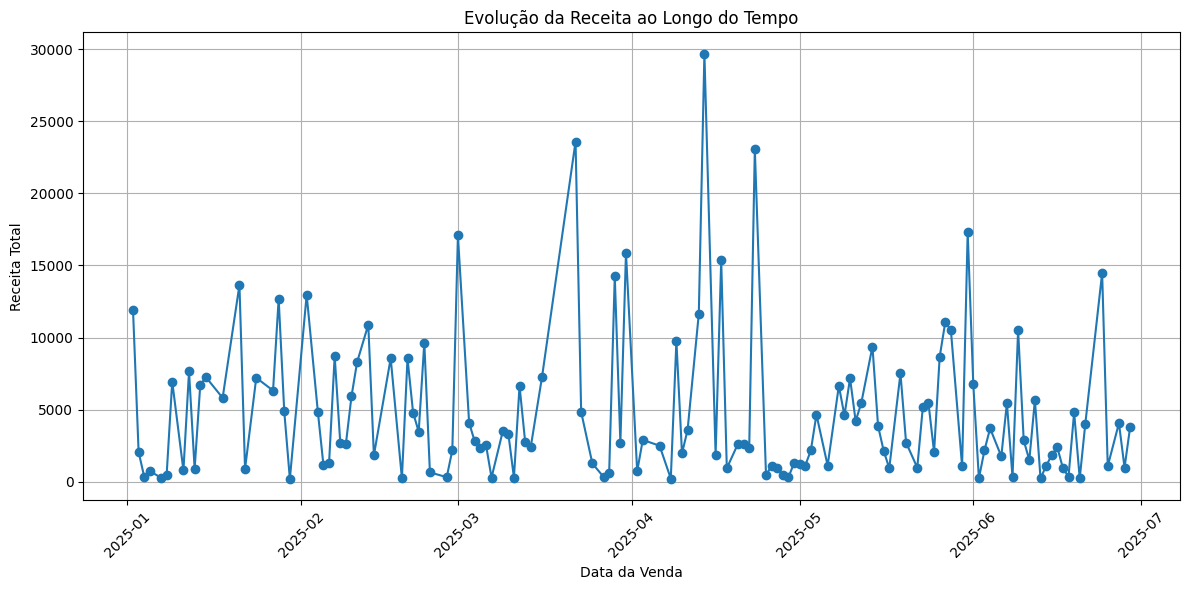

Este gráfico de linha mostra como a receita variou ao longo do tempo.


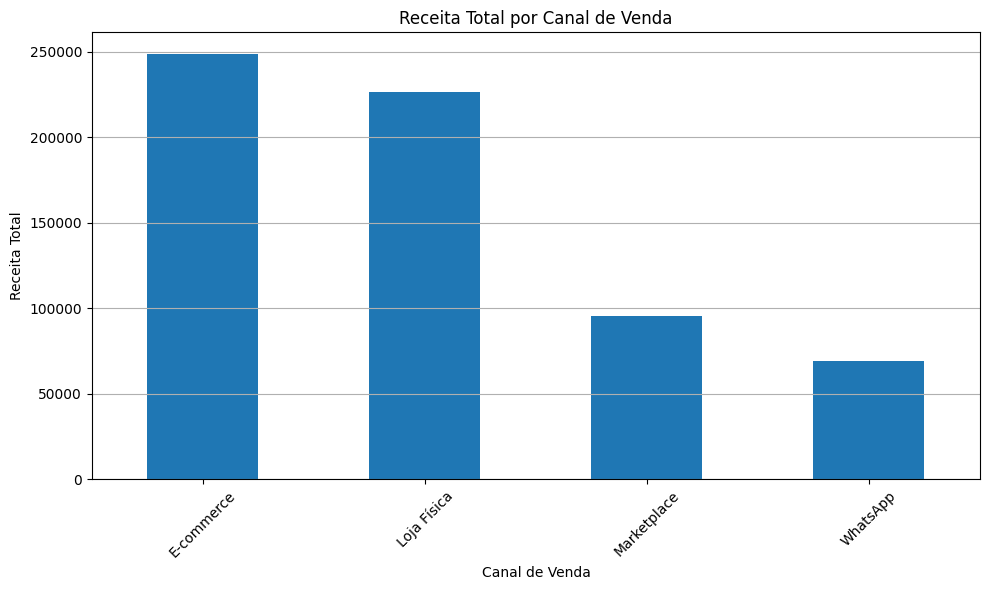

Interpretação: O gráfico de barras facilita a comparação direta entre os canais de venda, mostrando qual deles contribui mais para a receita total. No nosso caso, 'Loja Física' e 'E-commerce' são os maiores geradores de receita.


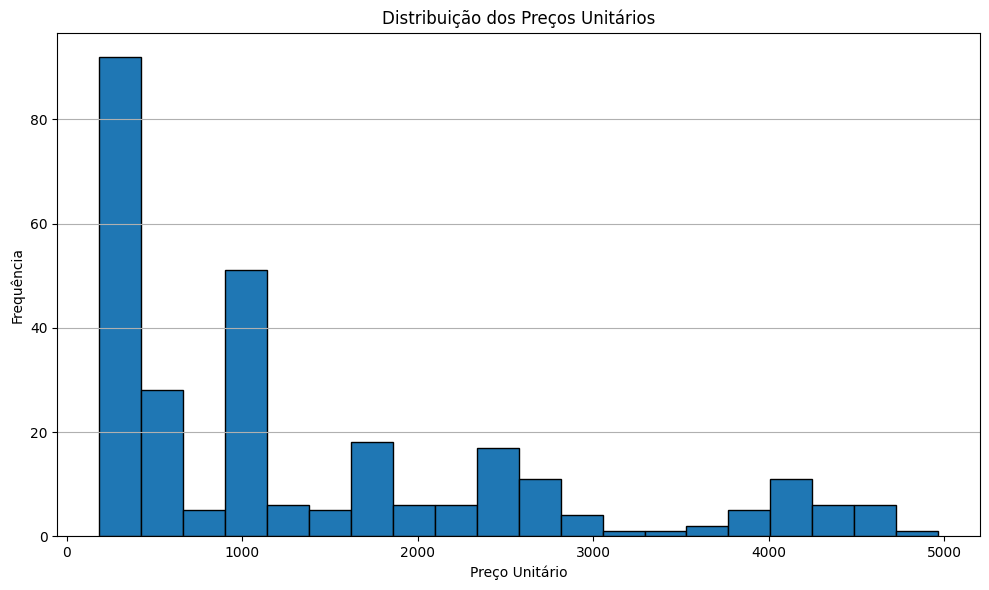

Interpretação: O histograma mostra a frequência com que diferentes faixas de preços unitários aparecem no dataset. Ele ajuda a entender a distribuição dos produtos vendidos, se a maioria é de baixo, médio ou alto custo, e se há alguma concentração de preços.


In [46]:
# a) Gráfico de linha para evolução da receita ao longo do tempo
# Agrupar por data e somar a receita
receita_por_data = df_cleaned.groupby('Data_Venda')['Receita'].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(receita_por_data['Data_Venda'], receita_por_data['Receita'], marker='o', linestyle='-')
plt.title('Evolução da Receita ao Longo do Tempo')
plt.xlabel('Data da Venda')
plt.ylabel('Receita Total')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Este gráfico de linha mostra como a receita variou ao longo do tempo.")

# b) Gráfico de barras para comparar a receita entre canais de venda
# Agrupar por canal de venda e somar a receita
receita_por_canal = df_cleaned.groupby('Canal_Venda')['Receita'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
receita_por_canal.plot(kind='bar')
plt.title('Receita Total por Canal de Venda')
plt.xlabel('Canal de Venda')
plt.ylabel('Receita Total')
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Gráfico de barras facilita a comparação direta entre os canais de venda")

# c) Histograma para a distribuição dos preços unitários
plt.figure(figsize=(10, 6))
plt.hist(df_cleaned['Preco_Unitario'], bins=20, edgecolor='black')
plt.title('Distribuição dos Preços Unitários')
plt.xlabel('Preço Unitário')
plt.ylabel('Frequência')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

print("O histograma mostra a frequência com que diferentes faixas de preços unitários aparecem")


## Desafio extra (opcional)

Faça uma pequena limpeza no dataset:

- trate valores nulos;
- padronize os nomes dos canais de venda;
- converta `Data_Venda` para formato de data.

Depois, compare os resultados **antes e depois da limpeza**.

In [44]:
# Sua resposta aqui
# 1. Converter 'Data_Venda' para formato de data
df['Data_Venda'] = pd.to_datetime(df['Data_Venda'])

# 2. Padronizar os nomes dos canais de venda
df['Canal_Venda'] = df['Canal_Venda'].replace({
    'loja fisica': 'Loja Física',
    'e-commerce': 'E-commerce'
}, regex=True)

# 3. Tratar valores nulos: para fins de visualização, preencher com a média ou modo pode ser uma opção simples.
# Para os gráficos, é mais seguro remover as linhas com nulos nas colunas que serão usadas.
df_cleaned = df.dropna(subset=['Canal_Venda', 'UF', 'Preco_Unitario', 'Data_Venda']).copy()

print("Dataset após a limpeza inicial para gráficos:")
display(df_cleaned.head())
print("Valores nulos após limpeza:")
display(df_cleaned.isnull().sum())

print(f"Número de linhas antes da limpeza: {len(df)}")
print(f"Número de linhas depois da limpeza para gráficos: {len(df_cleaned)}")

Dataset após a limpeza inicial para gráficos:


,Data_Venda,Canal_Venda,UF,Produto,Preco_Unitario,Quantidade,Custo_Unitario,Receita,Lucro
0,2025-04-13,Loja Física,SP,Smartphone,2484.58,3,1872.49,7453.74,1836.27
1,2025-06-29,Loja Física,RJ,Smartwatch,1041.91,1,699.66,1041.91,342.25
2,2025-04-03,E-commerce,RJ,Smartphone,2447.07,1,2077.09,2447.07,369.98
3,2025-01-15,Loja Física,MG,Smartphone,2307.40,1,1797.67,2307.40,509.73
4,2025-04-17,E-commerce,PR,Notebook,3840.18,4,3069.45,15360.72,3082.92


Valores nulos após limpeza:


,0
Data_Venda,0
Canal_Venda,0
UF,0
Produto,0
Preco_Unitario,0
Quantidade,0
Custo_Unitario,0
Receita,0
Lucro,0


Número de linhas antes da limpeza: 300
Número de linhas depois da limpeza para gráficos: 282


## Entrega esperada

Ao final, seu notebook deve conter:

- leitura do dataset;
- inspeção inicial;
- análise de qualidade dos dados;
- cálculo de KPIs;
- respostas às perguntas de negócio;
- pelo menos um gráfico;
- comentários interpretando os resultados.

---
### Reflexão final
Explique em 4 a 6 linhas:

**Por que uma análise de dados não deve se limitar a “fazer gráficos bonitos”?**

In [ ]:
print("Por que uma análise de dados não deve se limitar a “fazer gráficos bonitos?")
print("Validação e integridade dos dados, analisando padroes e tratando os valores ")